In [ ]:

!pip install newsapi-python


import requests
import pandas as pd

In [ ]:
!pip install nltk

import nltk
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    return sia.polarity_scores(text)['compound']

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
api_key = "dbc32f1a3a4e4a52a3f91601ef7e6ffd"

url = f"https://newsapi.org/v2/everything?q=Apple&pageSize=100&apiKey={api_key}"

response = requests.get(url)
data = response.json()

articles = data['articles']

headlines = []
dates = []

for article in articles:
    headlines.append(article['title'])
    dates.append(article['publishedAt'][:10])  # get only date

df_news = pd.DataFrame({
    "date": dates,
    "headline": headlines
})

df_news.head()

,date,headline
0,2026-03-27,Rank the 50 best Apple products
1,2026-03-03,"New MacBooks, the iPhone 17E, and more: everyt..."
2,2026-03-30,Between Jobs
3,2026-03-03,The Untold Story of the Birth of the iPhone
4,2026-03-02,Apple might use Google servers to store data f...


In [ ]:


df_news['sentiment'] = df_news['headline'].apply(get_sentiment)

df_news.head()

,date,headline,sentiment
0,2026-03-27,Rank the 50 best Apple products,0.6369
1,2026-03-03,"New MacBooks, the iPhone 17E, and more: everyt...",0.0000
2,2026-03-30,Between Jobs,0.0000
3,2026-03-03,The Untold Story of the Birth of the iPhone,0.0000
4,2026-03-02,Apple might use Google servers to store data f...,0.0000


In [ ]:
daily = df_news.groupby('date')['sentiment'].agg(['mean', 'count']).reset_index()

import numpy as np
daily['sentiment'] = daily['mean'] * np.log1p(daily['count'])

df_daily_sentiment = daily[['date', 'sentiment']]

df_daily_sentiment.head()

,date,sentiment
0,2026-03-02,0.000000
1,2026-03-03,-0.110268
2,2026-03-04,0.000000
3,2026-03-05,-0.271302
4,2026-03-06,0.342345


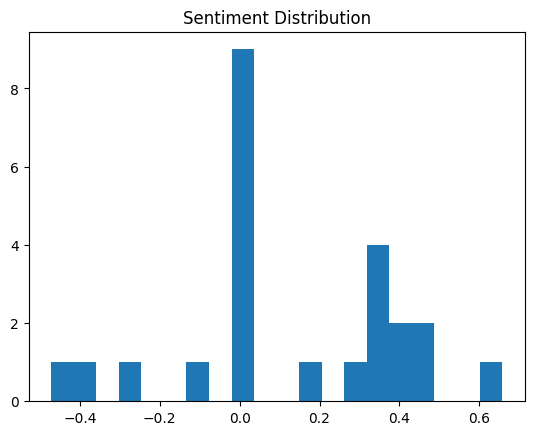

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_daily_sentiment['sentiment'], bins=20)
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
daily_sentiment = df_daily_sentiment['sentiment'].mean()
print("Daily Sentiment:", daily_sentiment)

Daily Sentiment: 0.11090658569825239


In [ ]:
df_daily_sentiment.to_csv("daily_sentiment.csv", index=False)

In [ ]:
df_daily_sentiment.to_csv("daily_sentiment.csv", index=False)

In [ ]:
from google.colab import files
files.download("daily_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>